In [12]:
import math
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# config
PARQUET_PATH = Path("df_cleaned_reg.parquet")
TARGET_COL = "hammer_price_usd_real"

INCLUDE_ESTIMATES = False
INCLUDE_ARTIST_NAME = True
RANDOM_STATE = 42

# helpers
def first_existing(candidates: List[str], cols: pd.Index) -> str | None:
    for c in candidates:
        if c in cols:
            return c
    return None

# load data
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Could not find {PARQUET_PATH.resolve()}")

df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded data with shape: {df.shape}")

if TARGET_COL not in df.columns:
    similar = [c for c in df.columns if "hammer" in c.lower() or "price" in c.lower()]
    raise KeyError(
        f"{TARGET_COL} not found.\n"
        f"Available price-like columns: {similar}"
    )

Loaded data with shape: (6283076, 37)


In [3]:
# identify columns
auction_date_col = first_existing(["auction_start_date"], df.columns)
auction_house_col = first_existing(["auction_house_name"], df.columns)
auction_location_col = first_existing(["auction_location"], df.columns)
currency_col = first_existing(["currency"], df.columns)

artist_name_col = first_existing(["artist_name"], df.columns)
artist_nationality_col = first_existing(["artist_nationality"], df.columns)
artist_gender_col = first_existing(["artist_gender"], df.columns)
artist_birth_col = first_existing(["artist_birth_year", "artist_birth"], df.columns)
artist_death_col = first_existing(["artist_death_year", "artist_death"], df.columns)

medium_col = first_existing(["medium_final"], df.columns)
genre_col = first_existing(["artist_genre"], df.columns)
continent_col = first_existing(["artist_continent"], df.columns)

lot_num_col = first_existing(["lot_num"], df.columns)
width_col = first_existing(["artwork_measurements_width"], df.columns)
height_col = first_existing(["artwork_measurements_height"], df.columns)
depth_col = first_existing(["artwork_measurements_depth"], df.columns)
creation_year_col = first_existing(["artwork_creation_year"], df.columns)

signed_col = first_existing(["signed"], df.columns)
provenance_col = first_existing(["has_provenance", "artwork_provenance"], df.columns)
exhibited_col = first_existing(["exhibited", "artwork_exhibited"], df.columns)
literature_col = first_existing(["has_literature", "artwork_literature"], df.columns)
bought_in_col = first_existing(["bought_in"], df.columns)

estimate_min_col = first_existing(
    ["price_estimate_min_usd_real", "price_estimate_min_usd_zeroied_real"],
    df.columns,
)
estimate_max_col = first_existing(
    ["price_estimate_max_usd_real", "price_estimate_max_usd_zeroied_real"],
    df.columns,
)

In [4]:
# model sample
df_model = df.copy()

# sold lots only, positive hammer prices only
df_model = df_model[df_model[TARGET_COL].notna()]
df_model = df_model[df_model[TARGET_COL] > 0]

if bought_in_col is not None:
    df_model = df_model[(df_model[bought_in_col].isna()) | (df_model[bought_in_col] == 0)]

# date features
if auction_date_col is not None:
    df_model[auction_date_col] = pd.to_datetime(df_model[auction_date_col], errors="coerce")
    df_model["auction_year"] = df_model[auction_date_col].dt.year
    df_model["auction_month"] = df_model[auction_date_col].dt.month
else:
    if "auction_year" not in df_model.columns:
        raise ValueError("Need either auction_start_date or auction_year.")
    df_model["auction_month"] = np.nan

# numeric conversion
for c in [artist_birth_col, artist_death_col, lot_num_col, width_col, height_col, depth_col, creation_year_col]:
    if c is not None and c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

# derived artist features
if artist_birth_col is not None:
    df_model["artist_age_at_sale"] = df_model["auction_year"] - df_model[artist_birth_col]
else:
    df_model["artist_age_at_sale"] = np.nan

if artist_death_col is not None:
    df_model["years_since_death"] = df_model["auction_year"] - df_model[artist_death_col]
    df_model.loc[df_model["years_since_death"] < 0, "years_since_death"] = np.nan
else:
    df_model["years_since_death"] = np.nan

# log target
df_model["y_log_price"] = np.log(df_model[TARGET_COL].astype(float))

In [5]:
# feature selection
numeric_features = [
    c for c in [
        lot_num_col,
        width_col,
        height_col,
        depth_col,
        creation_year_col,
        "auction_year",
        "auction_month",
        "artist_age_at_sale",
        "years_since_death",
    ]
    if c is not None and c in df_model.columns
]

categorical_features = [
    c for c in [
        auction_house_col,
        auction_location_col,
        currency_col,
        medium_col,
        artist_nationality_col,
        artist_gender_col,
        genre_col,
        continent_col,
    ]
    if c is not None and c in df_model.columns
]

binary_features = [
    c for c in [
        signed_col,
        provenance_col,
        exhibited_col,
        literature_col,
    ]
    if c is not None and c in df_model.columns
]

if INCLUDE_ARTIST_NAME and artist_name_col is not None:
    categorical_features.append(artist_name_col)

# Only add estimates if explicitly requested
if INCLUDE_ESTIMATES:
    for c in [estimate_min_col, estimate_max_col]:
        if c is not None and c in df_model.columns:
            numeric_features.append(c)

feature_cols = numeric_features + categorical_features + binary_features
feature_cols = [c for c in feature_cols if c in df_model.columns]

print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nBinary features:", binary_features)

X = df_model[feature_cols].copy()
y = df_model["y_log_price"].copy()


Numeric features: ['lot_num', 'artwork_measurements_width', 'artwork_measurements_height', 'artwork_measurements_depth', 'artwork_creation_year', 'auction_year', 'auction_month', 'artist_age_at_sale', 'years_since_death']

Categorical features: ['auction_house_name', 'auction_location', 'currency', 'medium_final', 'artist_nationality', 'artist_gender', 'artist_genre', 'artist_continent', 'artist_name']

Binary features: ['signed', 'has_provenance', 'exhibited', 'has_literature']


In [6]:
# time-based split
years = sorted(df_model["auction_year"].dropna().unique())
if len(years) < 5:
    raise ValueError(f"Too few years for time split. Found only: {years}")

test_years = set(years[-2:])
val_years = set(years[-4:-2])
train_years = set(years[:-4])

train_mask = df_model["auction_year"].isin(train_years)
val_mask = df_model["auction_year"].isin(val_years)
test_mask = df_model["auction_year"].isin(test_years)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"\nTrain rows: {len(X_train):,}")
print(f"Val rows:   {len(X_val):,}")
print(f"Test rows:  {len(X_test):,}")
print(f"Train years: {sorted(train_years)}")
print(f"Val years:   {sorted(val_years)}")
print(f"Test years:  {sorted(test_years)}")


Train rows: 4,808,440
Val rows:   47,765
Test rows:  62,297
Train years: [np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)]
Val years:   [np.int32(2020), np.int32(2023)]
Test years:  [np.int32(2024), np.int32(2025)]


In [7]:
# preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", binary_transformer, binary_features),
    ],
    remainder="drop",
)

In [8]:
# neural network pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(10, 10),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=1024,
        learning_rate_init=1e-3,
        max_iter=15,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3,
        random_state=RANDOM_STATE,
        verbose=True,
    )),
])

# fit on training set
model.fit(X_train, y_train)

# predict
val_pred_log = model.predict(X_val)
test_pred_log = model.predict(X_test)

# metrics in log space
val_r2_log = r2_score(y_val, val_pred_log)
test_r2_log = r2_score(y_test, test_pred_log)

# metrics in dollar space
val_true_usd = np.exp(y_val)
val_pred_usd = np.exp(val_pred_log)
test_true_usd = np.exp(y_test)
test_pred_usd = np.exp(test_pred_log)

val_mae_usd = mean_absolute_error(val_true_usd, val_pred_usd)
test_mae_usd = mean_absolute_error(test_true_usd, test_pred_usd)

val_rmse_usd = math.sqrt(mean_squared_error(val_true_usd, val_pred_usd))
test_rmse_usd = math.sqrt(mean_squared_error(test_true_usd, test_pred_usd))

print("\n==== Validation metrics ====")
print(f"R² on log price: {val_r2_log:.4f}")
print(f"MAE in USD:      {val_mae_usd:,.2f}")
print(f"RMSE in USD:     {val_rmse_usd:,.2f}")

print("\n==== Test metrics ====")
print(f"R² on log price: {test_r2_log:.4f}")
print(f"MAE in USD:      {test_mae_usd:,.2f}")
print(f"RMSE in USD:     {test_rmse_usd:,.2f}")

Iteration 1, loss = 1.88575483
Validation score: 0.680872
Iteration 2, loss = 1.28466484
Validation score: 0.703761
Iteration 3, loss = 0.86535628
Validation score: 0.713033
Iteration 4, loss = 21.28627003
Validation score: 0.708890
Iteration 5, loss = 12.79092648
Validation score: 0.714653
Iteration 6, loss = 7.67614956
Validation score: 0.719526
Iteration 7, loss = 5.23487060
Validation score: 0.720062
Iteration 8, loss = 3.43844048
Validation score: 0.720060
Iteration 9, loss = 2.23982273
Validation score: 0.721046
Iteration 10, loss = 1.41144840
Validation score: 0.720399
Iteration 11, loss = 0.88309824
Validation score: 0.663856
Iteration 12, loss = 0.57967701
Validation score: 0.720771
Iteration 13, loss = 0.44044384
Validation score: 0.719515
Validation score did not improve more than tol=0.000100 for 3 consecutive epochs. Stopping.

==== Validation metrics ====
R² on log price: 0.5174
MAE in USD:      101,450.62
RMSE in USD:     1,235,903.03

==== Test metrics ====
R² on log pr

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# baseline test performance
baseline_pred = model.predict(X_test)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline test R^2:", round(baseline_r2, 4))

def grouped_permutation_importance(model, X_test, y_test, feature_cols, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    for col in feature_cols:
        drops = []

        for _ in range(n_repeats):
            X_perm = X_test.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)

            perm_pred = model.predict(X_perm)
            perm_r2 = r2_score(y_test, perm_pred)
            drop = baseline_r2 - perm_r2
            drops.append(drop)

        results.append({
            "feature": col,
            "importance_mean_r2_drop": np.mean(drops),
            "importance_std_r2_drop": np.std(drops),
        })

    return pd.DataFrame(results).sort_values(
        "importance_mean_r2_drop", ascending=False
    ).reset_index(drop=True)

perm_importance = grouped_permutation_importance(
    model=model,
    X_test=X_test,
    y_test=y_test,
    feature_cols=feature_cols,
    n_repeats=5,
    random_state=42,
)

print(perm_importance.head(20))
perm_importance.to_csv("nn_permutation_importance.csv", index=False)

Baseline test R^2: 0.5439
                        feature  importance_mean_r2_drop  \
0                   artist_name                 0.549943   
1                  medium_final                 0.336868   
2   artwork_measurements_height                 0.158901   
3              auction_location                 0.028637   
4            artist_nationality                 0.017652   
5            artist_age_at_sale                 0.017193   
6              artist_continent                 0.014518   
7            auction_house_name                 0.005856   
8                     exhibited                 0.005456   
9                has_literature                 0.005018   
10                 artist_genre                 0.004046   
11                artist_gender                 0.002856   
12                       signed                 0.002484   
13            years_since_death                 0.002191   
14                      lot_num                 0.001970   
15   artwork_m

In [10]:
feature_groups = {
    "artist_identity": ["artist_name"],
    "artist_background": [
        "artist_nationality", "artist_gender", "artist_genre",
        "artist_continent", "artist_age_at_sale", "years_since_death"
    ],
    "object_characteristics": [
        "artwork_measurements_width", "artwork_measurements_height",
        "artwork_measurements_depth", "artwork_creation_year",
        "medium_final"
    ],
    "institutional_signals": [
        "signed", "has_provenance", "exhibited", "has_literature"
    ],
    "sale_structure": [
        "auction_house_name", "auction_location", "currency",
        "auction_year", "auction_month", "lot_num"
    ],
}

# keep only groups/columns that actually exist
feature_groups = {
    g: [c for c in cols if c in X_test.columns]
    for g, cols in feature_groups.items()
}
feature_groups = {g: cols for g, cols in feature_groups.items() if len(cols) > 0}

def grouped_family_importance(model, X_test, y_test, feature_groups, n_repeats=3, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    baseline_pred = model.predict(X_test)
    baseline_r2 = r2_score(y_test, baseline_pred)

    for group_name, cols in feature_groups.items():
        drops = []

        for _ in range(n_repeats):
            X_perm = X_test.copy()

            for col in cols:
                X_perm[col] = rng.permutation(X_perm[col].values)

            perm_pred = model.predict(X_perm)
            perm_r2 = r2_score(y_test, perm_pred)
            drops.append(baseline_r2 - perm_r2)

        results.append({
            "group": group_name,
            "importance_mean_r2_drop": np.mean(drops),
            "importance_std_r2_drop": np.std(drops),
            "n_features": len(cols),
        })

    return pd.DataFrame(results).sort_values(
        "importance_mean_r2_drop", ascending=False
    ).reset_index(drop=True)

group_importance = grouped_family_importance(
    model=model,
    X_test=X_test,
    y_test=y_test,
    feature_groups=feature_groups,
    n_repeats=5,
    random_state=42,
)

print(group_importance)
group_importance.to_csv("nn_group_importance.csv", index=False)

                    group  importance_mean_r2_drop  importance_std_r2_drop  \
0         artist_identity                 0.553693                0.004560   
1  object_characteristics                 0.518900                0.001051   
2          sale_structure                 0.089700                0.001216   
3       artist_background                 0.059563                0.000625   
4   institutional_signals                 0.024539                0.000574   

   n_features  
0           1  
1           5  
2           6  
3           6  
4           4  


# Results presentation

In [13]:
test_results = X_test.copy()
test_results = test_results.reset_index(drop=True)

test_results["y_true_log"] = np.array(y_test.reset_index(drop=True))
test_results["y_pred_log"] = np.array(test_pred_log)
test_results["residual_log"] = test_results["y_true_log"] - test_results["y_pred_log"]

test_results["y_true_usd"] = np.exp(test_results["y_true_log"])
test_results["y_pred_usd"] = np.exp(test_results["y_pred_log"])

test_results["abs_residual_log"] = np.abs(test_results["residual_log"])

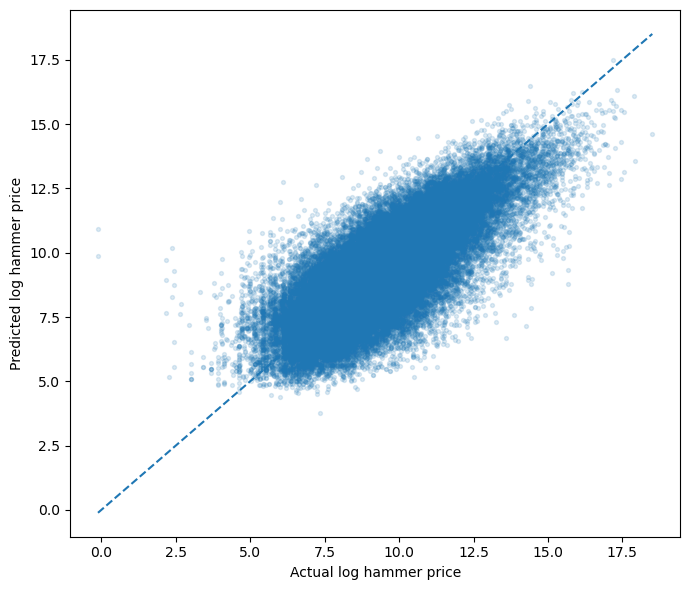

In [16]:
# actual vs. predicted log price
plt.figure(figsize=(7, 6))
plt.scatter(
    test_results["y_true_log"],
    test_results["y_pred_log"],
    alpha=0.15,
    s=8
)

min_val = min(test_results["y_true_log"].min(), test_results["y_pred_log"].min())
max_val = max(test_results["y_true_log"].max(), test_results["y_pred_log"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual log hammer price")
plt.ylabel("Predicted log hammer price")
plt.tight_layout()
plt.savefig("nn_actual_vs_predicted_logprice.png", dpi=300, bbox_inches="tight")
plt.show()

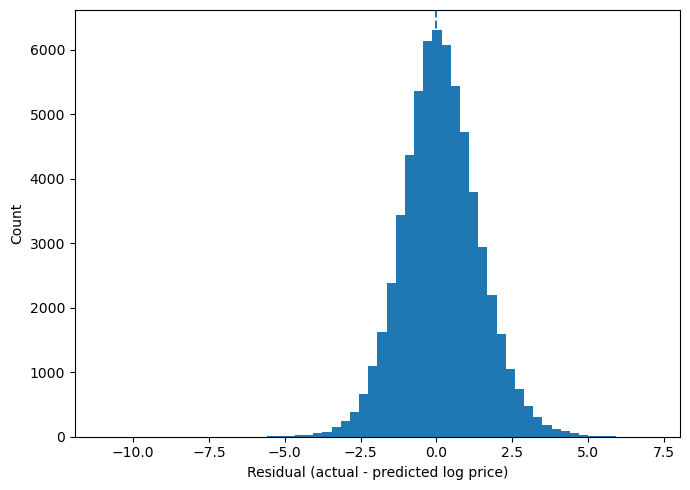

In [19]:
# residual histogram
plt.figure(figsize=(7, 5))
plt.hist(test_results["residual_log"], bins=60)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (actual - predicted log price)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("nn_residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

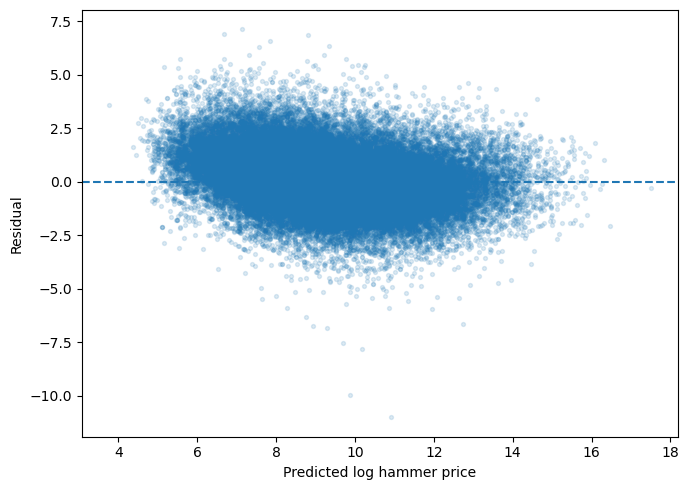

In [21]:
# residuals vs. predicted values
plt.figure(figsize=(7, 5))
plt.scatter(
    test_results["y_pred_log"],
    test_results["residual_log"],
    alpha=0.15,
    s=8
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log hammer price")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig("nn_residuals_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# model performance table
performance_table = pd.DataFrame({
    "Metric": [
        "Validation R^2 (log price)",
        "Test R^2 (log price)",
        "Validation MAE (USD)",
        "Test MAE (USD)",
        "Validation RMSE (USD)",
        "Test RMSE (USD)"
    ],
    "Value": [
        val_r2_log,
        test_r2_log,
        val_mae_usd,
        test_mae_usd,
        val_rmse_usd,
        test_rmse_usd
    ]
})

print(performance_table)
performance_table.to_csv("nn_performance_table.csv", index=False)

                       Metric         Value
0  Validation R^2 (log price)  5.174436e-01
1        Test R^2 (log price)  5.438976e-01
2        Validation MAE (USD)  1.014506e+05
3              Test MAE (USD)  9.876328e+04
4       Validation RMSE (USD)  1.235903e+06
5             Test RMSE (USD)  8.997040e+05
